# Forecast Evaluation of GMST Models Through 2025

This notebook reframes the project around your actual research question: how well do temperature models inspired by Foster–Rahmstorf (2011) and a 2024 reduced-complexity forcing-based setup predict global mean surface temperature after 2010, and how much forecast skill improves when we add more forcings, nonlinear terms, and autoregressive structure.

## Research Design

We compare four model families on an expanding-window forecast exercise for 2011–2025:

1. **Foster–Rahmstorf style baseline**: a linear trend plus short-term variability terms such as ENSO, volcanic aerosols, and solar variability.
2. **Reduced-complexity forcing model**: a regression driven by effective radiative forcing terms, intended as a transparent stand-in for a compact climate-response model.
3. **Extended statistical model**: the forcing model plus additional terms, nonlinearities, and interactions.
4. **Extended model with AR corrections**: the extended model plus autoregressive residual dynamics with lags 1, 2, and 3.

The notebook is written as a reproducible scaffold. It uses real model code, but expects you to provide consistent yearly input files for observed temperature and predictors.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg

plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data_forecasts"
DATA_DIR.mkdir(exist_ok=True)

TRAIN_END = 2010
TEST_START = 2011
TEST_END = 2025

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

print(f"Working directory: {ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Forecast evaluation window: {TEST_START}-{TEST_END}")

Working directory: /Users/owenhuang/Desktop/Climate
Data directory: /Users/owenhuang/Desktop/Climate/data_forecasts
Forecast evaluation window: 2011-2025


## Step 1: Prepare Comparable Yearly Datasets

Place the following CSV files in `data_forecasts/` before running the evaluation cell below. Keep one row per year and include at least the listed columns:

- `gmst.csv`: `year`, `temp`

  Observed global mean surface temperature anomaly. A practical starting point is HadCRUT4 or HadCRUT5 annual means.

- `fr_drivers.csv`: `year`, `enso`, `volcanic`, `solar`

  These are the classic short-term variability controls used in the Foster–Rahmstorf framework.

- `forcings.csv`: `year`, `anthro_erf`, `ghg_erf`, `aerosol_erf`, `solar_erf`, `volcanic_erf`, `ch4_erf`, `ods_erf`

  These provide a yearly forcing table for the reduced-complexity and extended models. If you have more forcing components, add them here and include them in the model specifications below.

If a file is missing, the next cell creates small template CSVs so you can fill them in with your chosen data sources.

In [2]:
def create_template_files(start=1970, end=2025):
    years = np.arange(start, end + 1)
    templates = {
        "gmst.csv": pd.DataFrame({"year": years, "temp": np.nan}),
        "fr_drivers.csv": pd.DataFrame(
            {
                "year": years,
                "enso": np.nan,
                "volcanic": np.nan,
                "solar": np.nan,
            }
        ),
        "forcings.csv": pd.DataFrame(
            {
                "year": years,
                "anthro_erf": np.nan,
                "ghg_erf": np.nan,
                "aerosol_erf": np.nan,
                "solar_erf": np.nan,
                "volcanic_erf": np.nan,
                "ch4_erf": np.nan,
                "ods_erf": np.nan,
            }
        ),
    }

    for filename, frame in templates.items():
        path = DATA_DIR / filename
        if not path.exists():
            frame.to_csv(path, index=False)
            print(f"Created template: {path}")

def load_csv(filename, required_columns):
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run create_template_files() or add the dataset manually."
        )

    frame = pd.read_csv(path)
    frame.columns = [str(col).strip().lower() for col in frame.columns]

    missing = sorted(set(required_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{filename} is missing required columns: {missing}")

    frame = frame.loc[:, ~frame.columns.duplicated()].copy()
    frame["year"] = frame["year"].astype(int)
    return frame.sort_values("year").reset_index(drop=True)

def load_inputs():
    gmst = load_csv("gmst.csv", ["year", "temp"])
    fr = load_csv("fr_drivers.csv", ["year", "enso", "volcanic", "solar"])
    forcings = load_csv(
        "forcings.csv",
        [
            "year",
            "anthro_erf",
            "ghg_erf",
            "aerosol_erf",
            "solar_erf",
            "volcanic_erf",
            "ch4_erf",
            "ods_erf",
        ],
    )

    data = gmst.merge(fr, on="year", how="inner").merge(forcings, on="year", how="inner")
    data = data[(data["year"] >= 1979) & (data["year"] <= TEST_END)].copy()
    data = data.dropna().reset_index(drop=True)

    if data.empty:
        raise ValueError(
            "Merged dataset is empty after alignment and dropna(). Run `python scripts/build_forecast_inputs.py` or fill the template CSVs manually, then rerun this cell."
        )

    return data

def show_template_status():
    status_rows = []
    for filename in ["gmst.csv", "fr_drivers.csv", "forcings.csv"]:
        frame = pd.read_csv(DATA_DIR / filename)
        value_columns = [col for col in frame.columns if col != "year"]
        filled_rows = int(frame[value_columns].notna().all(axis=1).sum())
        status_rows.append(
            {
                "file": filename,
                "rows": len(frame),
                "fully_filled_rows": filled_rows,
                "all_value_columns_empty": bool(frame[value_columns].isna().all().all()),
            }
        )
    return pd.DataFrame(status_rows)

create_template_files()
data = None

try:
    data = load_inputs()
    display(data.head())
except (FileNotFoundError, ValueError) as exc:
    print(exc)
    print("Template CSVs are ready in data_forecasts/. Run `python scripts/build_forecast_inputs.py` or populate them manually, then rerun this cell.")
    display(show_template_status())

,year,temp,enso,volcanic,solar,anthro_erf,ghg_erf,aerosol_erf,solar_erf,volcanic_erf,ch4_erf,ods_erf
0,1979,0.16,0.268333,0.147311,0.091890,0.467396,1.774603,-1.472339,0.091890,0.147311,0.421903,0.176349
1,1980,0.25,0.240000,0.109190,0.084245,0.526890,1.829507,-1.468288,0.084245,0.109190,0.429709,0.186499
2,1981,0.32,-0.198333,0.075737,0.086788,0.600280,1.872006,-1.437751,0.086788,0.075737,0.437018,0.197263
3,1982,0.14,0.870000,-0.156416,0.043450,0.646020,1.900693,-1.425690,0.043450,-0.156416,0.443611,0.207696
4,1983,0.31,1.145833,-0.677595,0.041625,0.708828,1.945883,-1.405792,0.041625,-0.677595,0.449270,0.218300


## Step 2: Define the Model Families

The models below are intentionally transparent so you can modify them easily.

- **FR baseline** uses a time trend with ENSO, volcanic, and solar terms.
- **Forcing model** uses a compact set of radiative forcing predictors as a simple reduced-complexity alternative.
- **Extended model** adds more forcing detail, a quadratic time term, and interactions.
- **AR variants** fit the extended model first, then forecast the residual with AR(1), AR(2), or AR(3).

The evaluation is recursive and strictly out of sample: for each target year from 2011 onward, the model is trained only on data available before that year.

In [3]:
def engineer_features(frame):
    frame = frame.copy()
    frame["time"] = frame["year"] - frame["year"].min()
    frame["time_sq"] = frame["time"] ** 2
    frame["enso_x_volcanic"] = frame["enso"] * frame["volcanic"]
    frame["ghg_minus_aerosol"] = frame["ghg_erf"] - frame["aerosol_erf"]
    return frame

MODEL_SPECS = {
    "foster_rahmstorf": ["time", "enso", "volcanic", "solar"],
    "forcing_rcm_like": [
        "anthro_erf",
        "solar_erf",
        "volcanic_erf",
        "ch4_erf",
        "ods_erf",
    ],
    "extended": [
        "time",
        "time_sq",
        "enso",
        "volcanic",
        "solar",
        "ghg_erf",
        "aerosol_erf",
        "solar_erf",
        "volcanic_erf",
        "ch4_erf",
        "ods_erf",
        "enso_x_volcanic",
        "ghg_minus_aerosol",
    ],
}

def fit_ols(train, features):
    X_train = sm.add_constant(train[features], has_constant="add")
    y_train = train["temp"]
    return sm.OLS(y_train, X_train, missing="drop").fit()

def one_step_residual_forecast(residuals, lag_order):
    residuals = pd.Series(residuals).dropna()
    if lag_order <= 0 or len(residuals) <= lag_order + 2:
        return 0.0

    model = AutoReg(residuals, lags=lag_order, old_names=False).fit()
    forecast = model.predict(start=len(residuals), end=len(residuals))
    return float(np.asarray(forecast)[0])

def recursive_forecast(data, features, start_year=TEST_START, end_year=TEST_END, ar_lag=0):
    rows = []

    for year in range(start_year, end_year + 1):
        train = data[data["year"] < year].copy()
        target = data[data["year"] == year].copy()

        if train.empty or target.empty:
            continue

        ols = fit_ols(train, features)
        X_target = sm.add_constant(target[features], has_constant="add")
        base_pred = float(ols.predict(X_target).iloc[0])

        fitted_train = pd.Series(ols.predict(sm.add_constant(train[features], has_constant="add")), index=train.index)
        residuals = train["temp"] - fitted_train
        correction = one_step_residual_forecast(residuals, ar_lag)
        final_pred = base_pred + correction

        rows.append(
            {
                "year": year,
                "actual": float(target["temp"].iloc[0]),
                "predicted": final_pred,
                "base_prediction": base_pred,
                "ar_correction": correction,
                "ar_lag": ar_lag,
            }
        )

    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError("No recursive forecasts were produced. Check the year coverage.")
    return out

if "data" not in globals() or data is None:
    try:
        data = load_inputs()
    except (FileNotFoundError, ValueError) as exc:
        raise RuntimeError(
            "No usable input data is loaded. Run `python scripts/build_forecast_inputs.py` or fill data_forecasts/gmst.csv, fr_drivers.csv, and forcings.csv manually, rerun Cell 4, then rerun this cell."
        ) from exc

data = engineer_features(data)
display(data.tail())

,year,temp,enso,volcanic,solar,anthro_erf,ghg_erf,aerosol_erf,solar_erf,volcanic_erf,ch4_erf,ods_erf,time,time_sq,enso_x_volcanic,ghg_minus_aerosol
42,2021,0.85,-1.180833,0.041934,-0.004412,2.692980,3.438421,-1.027904,-0.004412,0.041934,0.560198,0.376392,42,1764,-0.049516,4.466325
43,2022,0.89,-1.550000,0.027956,0.035424,2.741811,3.485556,-1.027591,0.035424,0.027956,0.563957,0.377353,43,1849,-0.043331,4.513146
44,2023,1.17,0.121667,0.013978,0.058013,2.789889,3.532002,-1.027277,0.058013,0.013978,0.567559,0.377798,44,1936,0.001701,4.559279
45,2024,1.28,-0.151667,0.000000,0.066868,2.837399,3.577942,-1.026963,0.066868,0.000000,0.571018,0.377881,45,2025,-0.000000,4.604904
46,2025,1.19,-0.887500,0.000000,0.044823,2.884445,3.623477,-1.026648,0.044823,0.000000,0.574344,0.377694,46,2116,-0.000000,4.650125


## Step 3: Evaluate Forecast Skill and Compare Extensions

This final section runs the expanding-window forecast exercise, scores each model on the 2011–2025 holdout, and plots predicted versus observed temperatures.

The key outputs to compare are:

- **RMSE** and **MAE** over 2011–2025
- whether forcing-based models outperform the FR-style baseline
- whether the quadratic and interaction terms improve skill
- whether AR(1), AR(2), or AR(3) residual corrections improve the extended model further

Once your input files are populated, this cell becomes the main experiment loop for answering your research question.

,model,rmse,mae,bias,n_forecasts
0,extended,0.103239,0.088748,-0.031652,15
1,extended_ar2,0.105894,0.088636,-0.030857,15
2,extended_ar3,0.107367,0.089831,-0.033723,15
3,extended_ar1,0.108235,0.091216,-0.031903,15
4,foster_rahmstorf,0.125633,0.101114,-0.074907,15
5,forcing_rcm_like,0.126279,0.104843,-0.042930,15


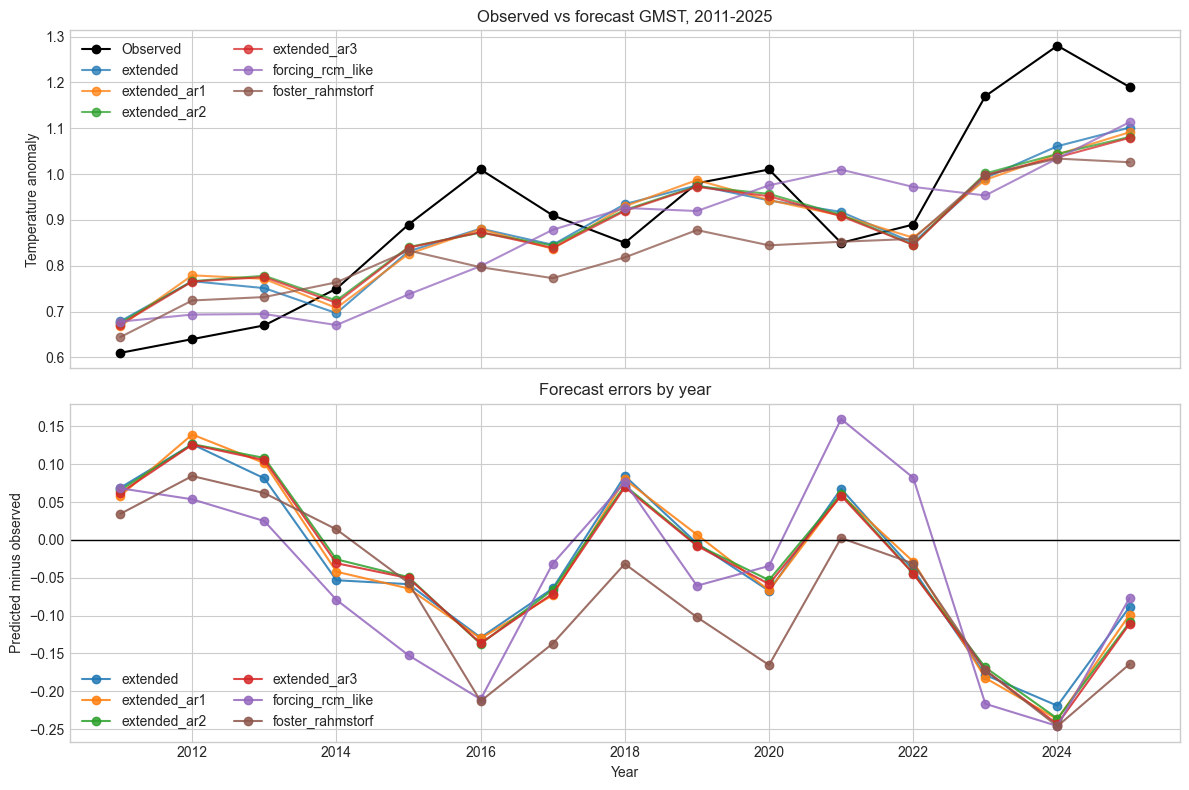

Best holdout model by RMSE: extended
Use the MODEL_SPECS dictionary to add variables, forcings, or interactions.
If AR terms help, the corresponding extended_ar* rows should move up the ranking.


In [4]:
if "data" not in globals() or data is None:
    try:
        data = engineer_features(load_inputs())
    except (FileNotFoundError, ValueError) as exc:
        raise RuntimeError(
            "No usable input data is loaded. Run `python scripts/build_forecast_inputs.py` or fill data_forecasts/gmst.csv, fr_drivers.csv, and forcings.csv manually, rerun Cell 4, then rerun this cell."
        ) from exc

experiments = [
    ("foster_rahmstorf", MODEL_SPECS["foster_rahmstorf"], 0),
    ("forcing_rcm_like", MODEL_SPECS["forcing_rcm_like"], 0),
    ("extended", MODEL_SPECS["extended"], 0),
    ("extended_ar1", MODEL_SPECS["extended"], 1),
    ("extended_ar2", MODEL_SPECS["extended"], 2),
    ("extended_ar3", MODEL_SPECS["extended"], 3),
]

score_rows = []
forecast_frames = []

for model_name, features, ar_lag in experiments:
    preds = recursive_forecast(data, features, ar_lag=ar_lag)
    preds["model"] = model_name
    forecast_frames.append(preds)

    score_rows.append(
        {
            "model": model_name,
            "rmse": rmse(preds["actual"], preds["predicted"]),
            "mae": mean_absolute_error(preds["actual"], preds["predicted"]),
            "bias": float((preds["predicted"] - preds["actual"]).mean()),
            "n_forecasts": len(preds),
        }
    )

scores = pd.DataFrame(score_rows).sort_values(["rmse", "mae"]).reset_index(drop=True)
all_forecasts = pd.concat(forecast_frames, ignore_index=True)

display(scores)

best_model = scores.loc[0, "model"]
best_forecasts = all_forecasts[all_forecasts["model"] == best_model].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(best_forecasts["year"], best_forecasts["actual"], marker="o", label="Observed", color="black")
for model_name, frame in all_forecasts.groupby("model"):
    axes[0].plot(frame["year"], frame["predicted"], marker="o", alpha=0.75, label=model_name)
axes[0].set_title("Observed vs forecast GMST, 2011-2025")
axes[0].set_ylabel("Temperature anomaly")
axes[0].legend(ncol=2)

for model_name, frame in all_forecasts.groupby("model"):
    axes[1].plot(
        frame["year"],
        frame["predicted"] - frame["actual"],
        marker="o",
        alpha=0.85,
        label=model_name,
    )
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Forecast errors by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Predicted minus observed")
axes[1].legend(ncol=2)

plt.tight_layout()
plt.show()

print(f"Best holdout model by RMSE: {best_model}")
print("Use the MODEL_SPECS dictionary to add variables, forcings, or interactions.")
print("If AR terms help, the corresponding extended_ar* rows should move up the ranking.")